In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Chargement du fichier
df = pd.read_excel('/content/US Superstore data (1).xls')

#Exploration et prétraitement des données
df.isnull().sum()
df.drop_duplicates()
df.describe()
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df["Year"] = df["Order Date"].dt.year
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015


Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


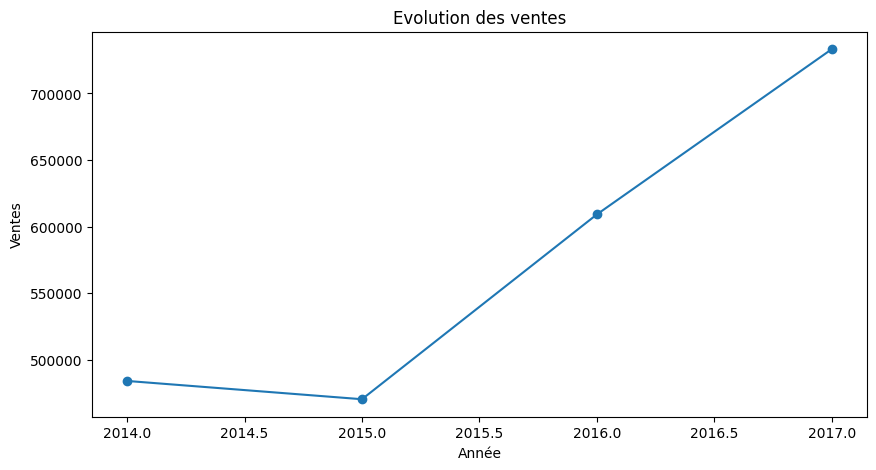

In [22]:
#Graphique linéaire interactif des tendances ventes au fil des années
  #Regrouper les ventes par année
sales_by_year = df.groupby('Year')['Sales'].sum()
print(sales_by_year)
  #Graphique linéaire

plt.figure(figsize=(10,5))

plt.plot(
    sales_by_year.index,
    sales_by_year.values,
    marker="o"
)

plt.title("Evolution des ventes")
plt.xlabel("Année")
plt.ylabel("Ventes")

plt.show()

le graphique nous indique que de 2014 à 2015, les ventes ont légèrement baissé; passant de 484000 à 470500. Mais à partir de 2015, on observe une augmentation fulgurante jusqu'à plus de 733000 en 2017.

In [40]:
#Visualisation matplotlib : Carte interactive des ventes par
  #regroupement par pays
state_sales = (
    df.groupby('State')['Sales']
    .sum()
    .sort_values(ascending= False)
    .reset_index()

)
print(state_sales)

  #Création  du treemap
fig = px.treemap(state_sales, path=['State'], values='Sales')
fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

                   State        Sales
0             California  457687.6315
1               New York  310876.2710
2                  Texas  170188.0458
3             Washington  138641.2700
4           Pennsylvania  116511.9140
5                Florida   89473.7080
6               Illinois   80166.1010
7                   Ohio   78258.1360
8               Michigan   76269.6140
9               Virginia   70636.7200
10        North Carolina   55603.1640
11               Indiana   53555.3600
12               Georgia   49095.8400
13              Kentucky   36591.7500
14            New Jersey   35764.3120
15               Arizona   35282.0010
16             Wisconsin   32114.6100
17              Colorado   32108.1180
18             Tennessee   30661.8730
19             Minnesota   29863.1500
20         Massachusetts   28634.4340
21              Delaware   27451.0690
22              Maryland   23705.5230
23          Rhode Island   22627.9560
24              Missouri   22205.1500
25          

L'Etat qu enregistre le plus de vente est la Californie.

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


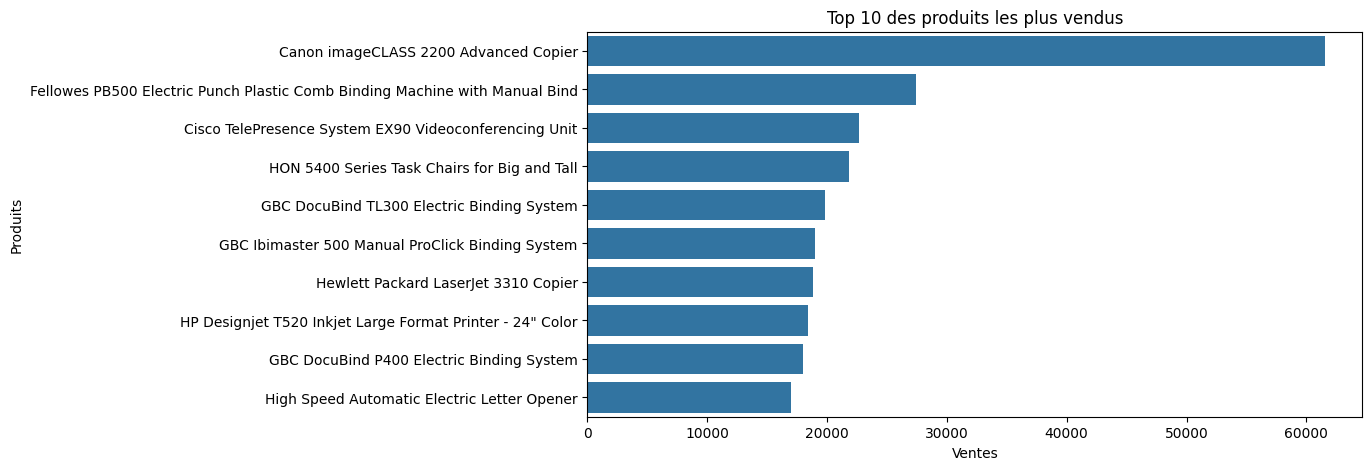

In [44]:
#Graphique seaborn montrant les 10 meilleurs produits par vente
top_10_produits = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending= False)
    .nlargest(10)
    )
print(top_10_produits)
plt.figure(figsize=(10,5))
sns.barplot(x=top_10_produits.values, y=top_10_produits.index)
plt.xlabel('Ventes')
plt.ylabel('Produits')
plt.title('Top 10 des produits les plus vendus')
plt.show()

A travers le grahique, on voit bien que le premier produit "Canon ImageClass 2200 Advanced copier" est très loin devant les autres. Tous les autres produits ont approximativement les mêmes ventes.

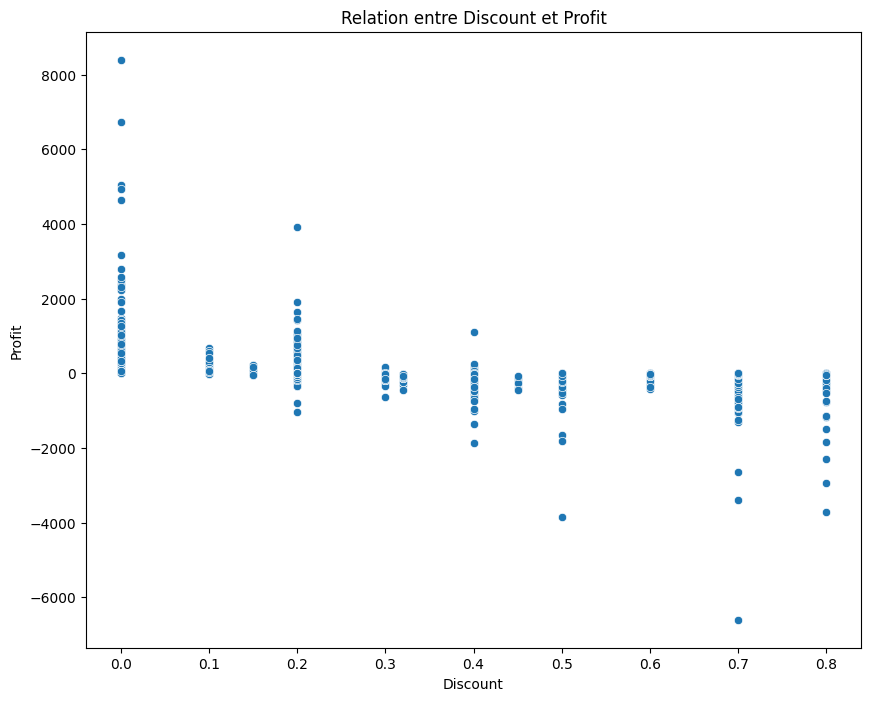

In [34]:
#Visualisation seaborn pour analyser la relation entre profit et discount
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Relation entre Discount et Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

On constate une corrélation négative entre les profits et les réductions. Les profits diminuent quand les réductions augmentent. Donc les réductions ne sont pas bénéfiques.

*Comparaison Matplotlib & Seaborn:*

Seaborn permet de créer rapidement des graphiques professionnels avec peu de code. Matplotlib offre davantage de personnalisation mais nécessite plus de configuration.


*Recommandations Business*
Les États présentant les ventes les plus élevées devraient recevoir davantage de budget marketing.

Les produits leaders devraient être davantage mis en avant dans les campagnes promotionnelles.

Certaines remises élevées semblent réduire fortement les profits ; il serait pertinent de réviser la politique de réduction.